In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.varmax import VARMAX # VARMA 대신 VARMAX로 수정
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 사용할 티커 리스트
tickers = ['TSLA', 'MP', 'LAZR', 'VALE', 'MGA', 'PLUG']
start_date = "2015-01-01"
end_date = "2025-11-13"

all_data = {}
for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        # 로그 수익률 계산
        df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
        all_data[ticker] = df[['Close', 'LogReturns']].dropna()
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

# 모든 기업의 로그 수익률을 하나의 데이터프레임으로 통합 (영업일 기준, inner join)
log_returns_df = pd.DataFrame()

for ticker, df in all_data.items():
    # 영업일 기준 리샘플링 및 결측치 처리
    df_resampled = df.asfreq('B').ffill()

    # 로그 수익률 컬럼 이름 변경
    log_returns_df[f'{ticker}_LogReturns'] = df_resampled['LogReturns']

# Inner Join을 통해 모든 기업이 공통으로 존재하는 기간만 사용
log_returns_df.dropna(how='any', inplace=True)
print(f"통합된 데이터 기간: {log_returns_df.index.min()} ~ {log_returns_df.index.max()}")
print(f"통합된 데이터 shape: {log_returns_df.shape}")

# TSLA Close Price 데이터도 최종 예측치 복원에 사용하기 위해 준비
tsla_close_df = all_data['TSLA']['Close'].asfreq('B').ffill().loc[log_returns_df.index]
log_returns_df['TSLA_Close'] = tsla_close_df

log_returns_df.head()

/tmp/ipython-input-1857309584.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1857309584.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1857309584.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1857309584.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-185730958

통합된 데이터 기간: 2020-06-23 00:00:00 ~ 2025-11-12 00:00:00
통합된 데이터 shape: (1407, 6)


,TSLA_LogReturns,MP_LogReturns,LAZR_LogReturns,VALE_LogReturns,MGA_LogReturns,PLUG_LogReturns,TSLA_Close
Date,,,,,,,
2020-06-23,0.007475,-0.009041,0.008713,0.031987,0.001366,0.143579,66.785332
2020-06-24,-0.041715,-0.013205,0.000000,-0.037740,-0.019530,0.163219,64.056664
2020-06-25,0.025818,0.012195,-0.007491,0.015268,0.014740,-0.029493,65.732002
2020-06-26,-0.026974,0.004032,-0.006601,-0.035666,-0.021258,-0.073376,63.982666
2020-06-29,0.050399,0.002913,0.002834,0.001961,0.023085,0.156866,67.290001


In [4]:
# --- 3. 정상성(Stationarity) 확인 (ADF Test) ---
# 로그 수익률은 대부분 정상성을 띠지만, 혹시 모를 변수를 위해 테스트
def check_stationarity(series):
    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    return p_value < 0.05 # True: Stationary

stationary_vars = []
for col in log_returns_df.columns:
    if col.endswith('_LogReturns'):
        is_stationary = check_stationarity(log_returns_df[col])
        print(f"{col}: Stationary = {is_stationary} (p-value: {adfuller(log_returns_df[col])[1]:.4f})")
        if is_stationary:
            stationary_vars.append(col)

# --- 4. TSLA Log Return과의 상관관계 확인 ---
correlation_matrix = log_returns_df[stationary_vars].corr()
tsla_corr = correlation_matrix['TSLA_LogReturns'].sort_values(ascending=False)
print("\nTSLA LogReturns와의 상관관계:")
print(tsla_corr)

# 상관관계가 높은 상위 3개(TSLA 제외) 변수 + TSLA LogReturns를 최종 VARMA 입력 변수로 선택
# 상관계수가 0.05보다 낮은 변수는 제외하는 기준을 적용할 수도 있으나, 여기서는 상관도가 높은 순으로 선택
# TSLA를 제외하고 상관관계가 높은 3개 종목 선택
top_correlated_vars = tsla_corr.index[1:4].tolist()
final_vars = ['TSLA_LogReturns'] + top_correlated_vars
print(f"\n최종 VARMA 입력 변수: {final_vars}")

TSLA_LogReturns: Stationary = True (p-value: 0.0000)
MP_LogReturns: Stationary = True (p-value: 0.0000)
LAZR_LogReturns: Stationary = True (p-value: 0.0000)
VALE_LogReturns: Stationary = True (p-value: 0.0000)
MGA_LogReturns: Stationary = True (p-value: 0.0000)
PLUG_LogReturns: Stationary = True (p-value: 0.0000)

TSLA LogReturns와의 상관관계:
TSLA_LogReturns    1.000000
PLUG_LogReturns    0.336247
MGA_LogReturns     0.326661
MP_LogReturns      0.281305
LAZR_LogReturns    0.281050
VALE_LogReturns    0.213102
Name: TSLA_LogReturns, dtype: float64

최종 VARMA 입력 변수: ['TSLA_LogReturns', 'PLUG_LogReturns', 'MGA_LogReturns', 'MP_LogReturns']


In [9]:
# 데이터 분리 (Train: 80%, Test: 20%)
test_size = int(0.2 * len(log_returns_df))
train_df = log_returns_df.iloc[:-test_size]
test_df = log_returns_df.iloc[-test_size:]

train_data = train_df[final_vars]
test_data = test_df[final_vars]

# --- 5. VAR 모델 최적 차수 p 탐색 (AIC 기준) ---
# VARMA는 차수 결정이 매우 어려우므로, 먼저 VAR 모델로 차수 p를 탐색합니다.
print("\nVAR Model Order Selection (AIC):")
var_model = VAR(train_data)
# 최대 차수 10까지 탐색 (Trade-off: 정확도 vs 계산 시간)
aic_results = var_model.select_order(maxlags=10)
optimal_p = aic_results.aic # aic_results.aic가 직접 최적 차수 값을 반환하는 것으로 가정

# optimal_p가 0인 경우 forecast 에러를 방지하기 위해 최소 1로 설정
if optimal_p == 0:
    optimal_p = 1
    print("AIC optimal order was 0, but set to 1 for practical forecasting with VAR.")

print(f"Optimal VAR Order (p): {optimal_p}")

# --- 6. 최종 VAR 모델 학습 및 예측 ---
# VARMA 대신, 차수 p가 결정된 VAR 모델을 사용합니다. (VARMA의 복잡성/안정성 문제 회피)
model = VAR(train_data)
results = model.fit(optimal_p)

# 테스트 기간 예측
lag_order = results.k_ar
forecast_input = train_data.values[-lag_order:]
pred = results.forecast(y=forecast_input, steps=len(test_data))
pred_df = pd.DataFrame(pred, index=test_data.index, columns=final_vars)

# 예측된 TSLA Log Return (VAR/VARMA 모델의 출력)
y_pred_log_return = pred_df['TSLA_LogReturns'].values
y_test_log_return = test_data['TSLA_LogReturns'].values


VAR Model Order Selection (AIC):
AIC optimal order was 0, but set to 1 for practical forecasting with VAR.
Optimal VAR Order (p): 1



     VAR (Multi-Company) Results    
Log Return MAE: 0.031132
Price MAE:      10.1577
Price RMSE:     13.5240
Price MAPE:     3.0346%
Direction Acc:  0.4643


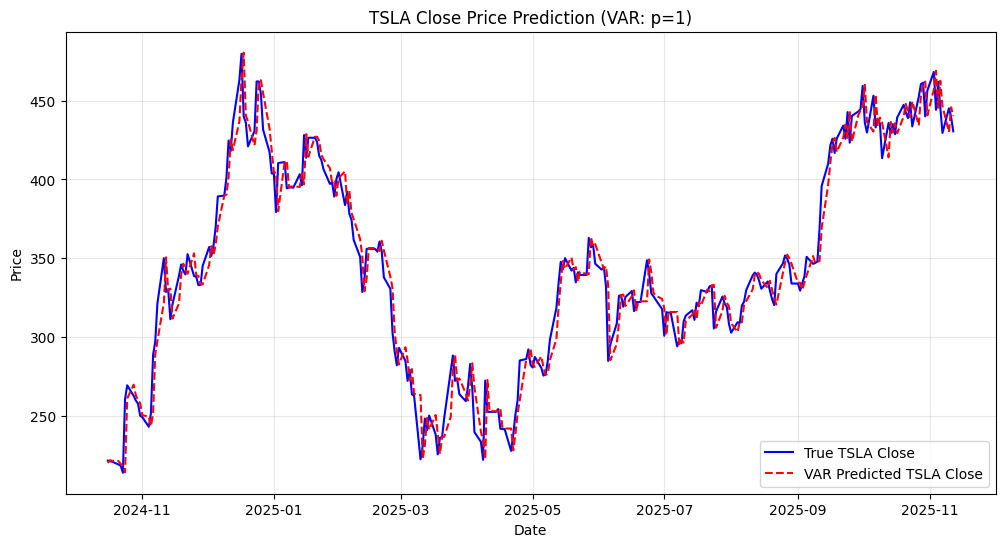

In [10]:
# --- 7. Log Return MAE 계산 (순수 예측력) ---
mae_log_return = mean_absolute_error(y_test_log_return, y_pred_log_return)

# --- 8. Log Return을 Close Price로 복원 및 가격 지표 계산 ---

# 이전 종가 (P_{t-1})
tsla_close_prev = log_returns_df['TSLA_Close'].iloc[-len(test_data)-1 : -1].values

# 실제 종가 (P_t)
y_test_price = log_returns_df['TSLA_Close'].iloc[-len(test_data):].values

# 예측 종가 (P_t = P_{t-1} * exp(Predicted Log Return))
y_pred_price = tsla_close_prev * np.exp(y_pred_log_return)

# 가격 지표
mae_price = mean_absolute_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
mape = np.mean(np.abs((y_test_price - y_pred_price) / y_test_price)) * 100

# 방향 예측 정확도 (Direction Accuracy)
# 실제: P_t - P_{t-1}, 예측: P_t_pred - P_{t-1}
# 실제 가격 변화의 부호와 예측 가격 변화의 부호가 일치하는 비율
direction_acc = np.mean(
    np.sign(np.diff(y_test_price)) == np.sign(np.diff(y_pred_price))
)


# --- 9. 결과 요약 ---
results_varma = {
    "Model": "VAR (Multi-Company)",
    "LogReturn_MAE": mae_log_return,
    "Price_MAE": mae_price,
    "Price_RMSE": rmse_price,
    "Price_MAPE": mape,
    "Direction_Acc": direction_acc
}

print("\n====================================")
print("     VAR (Multi-Company) Results    ")
print("====================================")
print(f"Log Return MAE: {results_varma['LogReturn_MAE']:.6f}")
print(f"Price MAE:      {results_varma['Price_MAE']:.4f}")
print(f"Price RMSE:     {results_varma['Price_RMSE']:.4f}")
print(f"Price MAPE:     {results_varma['Price_MAPE']:.4f}%")
print(f"Direction Acc:  {results_varma['Direction_Acc']:.4f}")

# --- 10. 시각화 ---
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test_price, label="True TSLA Close", color="blue")
plt.plot(test_data.index, y_pred_price, label="VAR Predicted TSLA Close", color="red", linestyle='--')
plt.title(f"TSLA Close Price Prediction (VAR: p={optimal_p})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
import pandas as pd
import numpy as np
import yfinance as yf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 재현을 위한 데이터 준비 함수
# ----------------------------------------------------
def column_add(df):
    df['Returns'] = df['Close'].pct_change()
    df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
    return df

def align_dates(df1, name1, df2, name2='tsla'):
    a = df1[['LogReturns']].dropna()
    b = df2[['Close','LogReturns']].dropna()
    df_merged = pd.concat([a, b], axis=1, join='inner', keys=[name1, name2])
    df_merged.columns = [f'{name1}_LogReturns',f'{name2}_Close', f'{name2}_LogReturns']
    return df_merged

# 데이터 다운로드 및 준비
start_date, end_date = "2015-01-01", "2025-11-13"
tsla = yf.download("TSLA", start=start_date, end=end_date)
tm = yf.download("TM", start=start_date, end=end_date)

tsla = column_add(tsla).dropna()
tm = column_add(tm).dropna()

# 영업일 기준 리샘플링
tsla = tsla.asfreq('B').ffill()
tm = tm.asfreq('B').ffill()

# 데이터 병합 및 전처리
merged_df = align_dates(df1=tm, name1='tm', df2=tsla)
merged_df['tsla_LogReturns2'] = merged_df['tsla_LogReturns'] # Unscaled target

scaler = StandardScaler()
# Log Returns (Index 0, 2)에 Standard Scaling 적용
merged_df.iloc[:, [0, 2]] = scaler.fit_transform(merged_df.iloc[:, [0, 2]])
tm_tsla = merged_df

# ----------------------------------------------------
# 2. 모델링 함수 재정의
# ----------------------------------------------------
def generate_dataset(df, input_idx, target_idx, window_size, test_n):
    x, y = [], []
    for i in range(len(df) - window_size):
        x.append(df.iloc[i:i+window_size, input_idx].values)
        y.append(df.iloc[i+window_size, target_idx])

    x = np.array(x)
    y = np.array(y)

    test_idx = len(df) - test_n
    split_point = test_idx - window_size

    x_train, y_train = x[:split_point], y[:split_point]
    x_test, y_test = x[split_point:], y[split_point:]

    x_train, x_val, y_train, y_val = train_test_split(
        x_train, y_train, test_size=0.1, shuffle=False
    )
    return x_train, y_train, x_val, y_val, x_test, y_test

def build_lstm(input_shape):
    model = keras.Sequential([
        keras.layers.LSTM(64, activation='tanh', input_shape=input_shape, return_sequences=False),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1)
    ])
    model.compile(loss='mae', optimizer=Adam(0.001), metrics=['mae'])
    return model

# ----------------------------------------------------
# 3. LSTM (TM & TSLA) Log Return MAE 계산 실행
# ----------------------------------------------------

df = tm_tsla
input_idx = [0, 2] # tm_LogReturns(scaled), tsla_LogReturns(scaled)
target_idx = 3     # tsla_LogReturns2(unscaled)
window_size = 20
test_n = int(0.2 * len(df))

x_train, y_train, x_val, y_val, x_test, y_test = generate_dataset(
    df, input_idx, target_idx, window_size, test_n
)

model = build_lstm((x_train.shape[1], x_train.shape[2]))
checkpoint_path = f"./best_lstm_tm_tsla_logmae.weights.h5"

cbk = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path, save_weights_only=True, monitor="val_mae", mode="min", save_best_only=True
)
es = keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)

# Train (Suppressing verbose output for clean presentation)
history = model.fit(
    x_train, y_train,
    epochs=200, batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[cbk, es],
    verbose=0
)

# Test
model.load_weights(checkpoint_path)
loss, mae_log_return_lstm = model.evaluate(x_test, y_test, verbose=0)
print(f"✅ LSTM (TM & TSLA) Test Log Return MAE: {mae_log_return_lstm:.6f}")

/tmp/ipython-input-4037914084.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsla = yf.download("TSLA", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4037914084.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tm = yf.download("TM", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


✅ LSTM (TM & TSLA) Test Log Return MAE: 0.027995
